In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.makedirs('/content/drive/MyDrive/Leukemia_Model1', exist_ok=True)
print("Folder ready!")

Folder ready!


In [3]:
from google.colab import files
uploaded = files.upload()

Saving ALL_IDB.zip to ALL_IDB.zip


In [4]:
from google.colab import files
uploaded = files.upload()

Saving C-NMC_Leukemia.zip to C-NMC_Leukemia.zip


In [5]:
!ls /content


ALL_IDB.zip  C-NMC_Leukemia.zip  drive	sample_data


In [6]:
!unzip /content/ALL_IDB.zip -d /content/ALL-IDB



Archive:  /content/ALL_IDB.zip
   creating: /content/ALL-IDB/ALL_IDB/Leukemia/
   creating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im064_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im065_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im066_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im067_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im0671_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im068_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im069_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im070_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im071_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im072_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im073_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im074_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB/Leukemia/L1/Im075_0.jpg  
  inflating: /content/ALL-IDB/ALL_IDB

In [7]:
!unzip /content/C-NMC_Leukemia.zip -d /content/C-NMC


Streaming output truncated to the last 5000 lines.
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_44_2_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_44_3_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_44_4_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_44_5_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_44_6_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_44_7_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_44_8_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_46_1_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_46_2_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_46_3_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_46_4_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_46_5_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_46_6_all.bmp  
  inflating: /content/C-NMC/fold_1/fold_1/all/UID_51_46_7_all.bmp

In [8]:
!ls /content


ALL-IDB  ALL_IDB.zip  C-NMC  C-NMC_Leukemia.zip  drive	sample_data


In [9]:
!ls /content/ALL-IDB/ALL_IDB
!ls /content/C-NMC


Leukemia  Normal
fold_0	fold_1	fold_2


In [10]:
import os
import cv2
import random
from tqdm import tqdm


In [11]:
ALL_IDB_PATH = "/content/ALL-IDB/ALL_IDB"   # has Leukemia / Normal
CNMC_PATH = "/content/C-NMC"                # has fold_0, fold_1, fold_2

OUT_PATH = "/content/Processed_Data"
IMG_SIZE = 224


In [12]:
for split in ["train", "val", "test"]:
    for cls in ["Leukemia", "Normal"]:
        os.makedirs(os.path.join(OUT_PATH, split, cls), exist_ok=True)


In [13]:
def preprocess_images(src_files, dst_folder):
    for img_path in tqdm(src_files):
        try:
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0
            name = os.path.basename(img_path)
            cv2.imwrite(os.path.join(dst_folder, name), (img * 255).astype("uint8"))
        except:
            pass


In [14]:
leuk_imgs = [os.path.join(ALL_IDB_PATH, "Leukemia", f)
             for f in os.listdir(os.path.join(ALL_IDB_PATH, "Leukemia"))]

norm_imgs = [os.path.join(ALL_IDB_PATH, "Normal", f)
             for f in os.listdir(os.path.join(ALL_IDB_PATH, "Normal"))]

random.shuffle(leuk_imgs)
random.shuffle(norm_imgs)


In [15]:
def split_list(lst, ratio=0.8):
    idx = int(len(lst) * ratio)
    return lst[:idx], lst[idx:]

leuk_train, leuk_val = split_list(leuk_imgs)
norm_train, norm_val = split_list(norm_imgs)


In [16]:
preprocess_images(leuk_train, os.path.join(OUT_PATH, "train", "Leukemia"))
preprocess_images(norm_train, os.path.join(OUT_PATH, "train", "Normal"))

preprocess_images(leuk_val, os.path.join(OUT_PATH, "val", "Leukemia"))
preprocess_images(norm_val, os.path.join(OUT_PATH, "val", "Normal"))


100%|██████████| 2/2 [00:00<00:00, 124.02it/s]
0it [00:00, ?it/s]
100%|██████████| 1/1 [00:00<00:00, 2964.17it/s]


In [17]:
!ls /content/C-NMC/fold_0


fold_0


In [18]:
!ls /content/C-NMC/fold_0/fold_0


all  hem


In [19]:
!ls /content/C-NMC/fold_0/*


all  hem


In [20]:
for fold in ["fold_0", "fold_1", "fold_2"]:
    leuk_path = os.path.join(CNMC_PATH, fold, fold, "all")   # extra fold
    norm_path = os.path.join(CNMC_PATH, fold, fold, "hem")

    leuk_files = [os.path.join(leuk_path, f) for f in os.listdir(leuk_path)]
    norm_files = [os.path.join(norm_path, f) for f in os.listdir(norm_path)]

    preprocess_images(leuk_files, os.path.join(OUT_PATH, "test", "Leukemia"))
    preprocess_images(norm_files, os.path.join(OUT_PATH, "test", "Normal"))




100%|██████████| 1096/1096 [00:04<00:00, 269.68it/s]


In [21]:
!ls /content/Processed_Data/test/Leukemia | head
!ls /content/Processed_Data/test/Normal | head


UID_1_10_1_all.bmp
UID_1_10_2_all.bmp
UID_1_10_3_all.bmp
UID_1_10_4_all.bmp
UID_11_10_1_all.bmp
UID_11_11_1_all.bmp
UID_11_11_2_all.bmp
UID_11_11_3_all.bmp
UID_1_11_1_all.bmp
UID_11_1_1_all.bmp
UID_H10_100_1_hem.bmp
UID_H10_100_2_hem.bmp
UID_H10_100_3_hem.bmp
UID_H10_100_4_hem.bmp
UID_H10_101_1_hem.bmp
UID_H10_10_1_hem.bmp
UID_H10_102_1_hem.bmp
UID_H10_102_2_hem.bmp
UID_H10_102_3_hem.bmp
UID_H10_102_4_hem.bmp


## Model-1

In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [23]:
!find /content -type d -name train


/content/Processed_Data/train


In [24]:
!find /content -maxdepth 3 -type d -name train


/content/Processed_Data/train


In [25]:
TRAIN_DIR = "/content/Processed_Data/train"
VAL_DIR   = "/content/Processed_Data/val"


In [26]:
!ls $TRAIN_DIR
!ls $TRAIN_DIR/Leukemia | head
!ls $TRAIN_DIR/Normal | head


Leukemia  Normal


In [27]:
!find /content/ALL-IDB -type d -maxdepth 4


find: warning: you have specified the global option -maxdepth after the argument -type, but global options are not positional, i.e., -maxdepth affects tests specified before it as well as those specified after it.  Please specify global options before other arguments.
/content/ALL-IDB
/content/ALL-IDB/ALL_IDB
/content/ALL-IDB/ALL_IDB/Leukemia
/content/ALL-IDB/ALL_IDB/Leukemia/L3
/content/ALL-IDB/ALL_IDB/Leukemia/L1
/content/ALL-IDB/ALL_IDB/Leukemia/L2
/content/ALL-IDB/ALL_IDB/Normal
/content/ALL-IDB/ALL_IDB/Normal/hem


In [28]:
!find /content/ALL-IDB -type f | head


/content/ALL-IDB/ALL_IDB/Leukemia/L3/Im004_1.tif
/content/ALL-IDB/ALL_IDB/Leukemia/L3/Im003_33.jpg
/content/ALL-IDB/ALL_IDB/Leukemia/L3/Im003_46.jpg
/content/ALL-IDB/ALL_IDB/Leukemia/L3/Im003_17.jpg
/content/ALL-IDB/ALL_IDB/Leukemia/L3/Im003_28.jpg
/content/ALL-IDB/ALL_IDB/Leukemia/L3/Im003_30.jpg
/content/ALL-IDB/ALL_IDB/Leukemia/L3/Im003_40.jpg
/content/ALL-IDB/ALL_IDB/Leukemia/L3/Im003_36.jpg
/content/ALL-IDB/ALL_IDB/Leukemia/L3/Im003_38.jpg
/content/ALL-IDB/ALL_IDB/Leukemia/L3/Im012_1.tif


In [29]:
import shutil, os

shutil.rmtree("/content/Processed_Data/train", ignore_errors=True)
shutil.rmtree("/content/Processed_Data/val", ignore_errors=True)

os.makedirs("/content/Processed_Data/train/Leukemia", exist_ok=True)
os.makedirs("/content/Processed_Data/train/Normal", exist_ok=True)
os.makedirs("/content/Processed_Data/val/Leukemia", exist_ok=True)
os.makedirs("/content/Processed_Data/val/Normal", exist_ok=True)


In [30]:
import cv2, random
from tqdm import tqdm

ALL_IDB_BASE = "/content/ALL-IDB/ALL_IDB"
OUT_PATH = "/content/Processed_Data"
IMG_SIZE = 224

def collect_images_from_subfolders(base_path):
    files = []
    for root, _, filenames in os.walk(base_path):
        for f in filenames:
            files.append(os.path.join(root, f))
    return files

def preprocess_and_save(files, dest):
    for img_path in tqdm(files):
        try:
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0
            name = os.path.basename(img_path)
            cv2.imwrite(os.path.join(dest, name), (img*255).astype("uint8"))
        except:
            pass


In [31]:
leuk_imgs = collect_images_from_subfolders(
    os.path.join(ALL_IDB_BASE, "Leukemia")
)

norm_imgs = collect_images_from_subfolders(
    os.path.join(ALL_IDB_BASE, "Normal")
)

# FIX: Set seed before shuffle so val set is always the same images
random.seed(42)
random.shuffle(leuk_imgs)

random.seed(42)
random.shuffle(norm_imgs)


In [32]:
def split_data(lst, ratio=0.8):
    idx = int(len(lst)*ratio)
    return lst[:idx], lst[idx:]

leuk_train, leuk_val = split_data(leuk_imgs)
norm_train, norm_val = split_data(norm_imgs)


In [33]:
preprocess_and_save(leuk_train, OUT_PATH+"/train/Leukemia")
preprocess_and_save(norm_train, OUT_PATH+"/train/Normal")

preprocess_and_save(leuk_val, OUT_PATH+"/val/Leukemia")
preprocess_and_save(norm_val, OUT_PATH+"/val/Normal")


100%|██████████| 226/226 [00:00<00:00, 326.93it/s]


In [34]:
!ls /content/Processed_Data/train/Leukemia | head
!ls /content/Processed_Data/train/Normal | head


Im0011_1.jpg
Im001_1.jpg
Im001_1.tif
Im002_1.tif
Im003_10.jpg
Im003_11.jpg
Im0031_1.jpg
Im003_12.jpg
Im003_13.jpg
Im003_14.jpg
UID_H11_10_1_hem.bmp
UID_H11_10_2_hem.bmp
UID_H11_11_1_hem.bmp
UID_H11_11_2_hem.bmp
UID_H11_1_1_hem.bmp
UID_H11_12_1_hem.bmp
UID_H11_12_2_hem.bmp
UID_H11_12_3_hem.bmp
UID_H11_13_1_hem.bmp
UID_H11_13_2_hem.bmp


In [35]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 16

TRAIN_DIR = "/content/Processed_Data/train"
VAL_DIR   = "/content/Processed_Data/val"

train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

val_data = val_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)


Found 1019 images belonging to 2 classes.
Found 256 images belonging to 2 classes.


In [36]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base = ResNet50(weights="imagenet", include_top=False,
                input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = GlobalAveragePooling2D()(base.output)
resnet = Model(base.input, x)
resnet.trainable = False

X_train = resnet.predict(train_data, verbose=1)
y_train = train_data.classes

X_val = resnet.predict(val_data, verbose=1)
y_val = val_data.classes


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 125ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


In [37]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [38]:
def fitness_function(feature_mask, X_train, y_train, X_val, y_val):
    # if no feature selected, return worst score
    if np.sum(feature_mask) == 0:
        return 0

    X_tr = X_train[:, feature_mask == 1]
    X_v  = X_val[:, feature_mask == 1]

    clf = SVC(kernel='rbf')
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_v)

    acc = accuracy_score(y_val, preds)
    return acc


In [39]:
def HHO(X_train, y_train, X_val, y_val, n_hawks=10, max_iter=10):
    n_features = X_train.shape[1]

    # Initialize hawks randomly (0/1 feature mask)
    hawks = np.random.randint(0, 2, (n_hawks, n_features))

    best_hawk = hawks[0]
    best_score = 0

    for it in range(max_iter):
        for i in range(n_hawks):
            score = fitness_function(
                hawks[i], X_train, y_train, X_val, y_val
            )

            if score > best_score:
                best_score = score
                best_hawk = hawks[i].copy()

        # Update hawks (exploration + exploitation)
        for i in range(n_hawks):
            rand = np.random.rand(n_features)
            hawks[i] = np.where(rand > 0.5, best_hawk, hawks[i])

        print(f"Iteration {it+1}/{max_iter} - Best Accuracy: {best_score:.4f}")

    return best_hawk


In [40]:
best_mask = HHO(
    X_train, y_train,
    X_val, y_val,
    n_hawks=8,
    max_iter=30
)

print("Selected features:", np.sum(best_mask))


Iteration 1/30 - Best Accuracy: 0.8828
Iteration 2/30 - Best Accuracy: 0.8828
Iteration 3/30 - Best Accuracy: 0.8828
Iteration 4/30 - Best Accuracy: 0.8828
Iteration 5/30 - Best Accuracy: 0.8828
Iteration 6/30 - Best Accuracy: 0.8828
Iteration 7/30 - Best Accuracy: 0.8828
Iteration 8/30 - Best Accuracy: 0.8828
Iteration 9/30 - Best Accuracy: 0.8828
Iteration 10/30 - Best Accuracy: 0.8828
Iteration 11/30 - Best Accuracy: 0.8828
Iteration 12/30 - Best Accuracy: 0.8828
Iteration 13/30 - Best Accuracy: 0.8828
Iteration 14/30 - Best Accuracy: 0.8828
Iteration 15/30 - Best Accuracy: 0.8828
Iteration 16/30 - Best Accuracy: 0.8828
Iteration 17/30 - Best Accuracy: 0.8828
Iteration 18/30 - Best Accuracy: 0.8828
Iteration 19/30 - Best Accuracy: 0.8828
Iteration 20/30 - Best Accuracy: 0.8828
Iteration 21/30 - Best Accuracy: 0.8828
Iteration 22/30 - Best Accuracy: 0.8828
Iteration 23/30 - Best Accuracy: 0.8828
Iteration 24/30 - Best Accuracy: 0.8828
Iteration 25/30 - Best Accuracy: 0.8828
Iteration

In [41]:
X_train_hho = X_train[:, best_mask == 1]
X_val_hho   = X_val[:, best_mask == 1]

print("Before HHO:", X_train.shape)
print("After HHO :", X_train_hho.shape)


Before HHO: (1019, 2048)
After HHO : (1019, 1025)


In [42]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [43]:
svm = SVC(
    kernel='rbf',
    C=5,                # reduce complexity
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)

In [44]:
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

svm.fit(X_train_hho, y_train)


SVC(C=10, probability=True, random_state=42)

In [45]:
val_pred = svm.predict(X_val_hho)

val_acc = accuracy_score(y_val, val_pred)
print("Validation Accuracy (ResNet50 + HHO + SVM):", val_acc)

print("\nClassification Report:\n")
print(classification_report(y_val, val_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, val_pred))


Validation Accuracy (ResNet50 + HHO + SVM): 0.90625

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.20      0.33        30
           1       0.90      1.00      0.95       226

    accuracy                           0.91       256
   macro avg       0.95      0.60      0.64       256
weighted avg       0.92      0.91      0.88       256


Confusion Matrix:

[[  6  24]
 [  0 226]]


In [46]:
!pip install -q transformers timm


In [47]:
import torch
from transformers import DeiTForImageClassification, DeiTImageProcessor
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [48]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])


In [49]:
train_dataset = datasets.ImageFolder(
    "/content/Processed_Data/train", transform=transform
)
val_dataset = datasets.ImageFolder(
    "/content/Processed_Data/val", transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [50]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = DeiTForImageClassification.from_pretrained(
    "facebook/deit-base-distilled-patch16-224",
    num_labels=2
)

model.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/349M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/349M [00:00<?, ?B/s]

DeiTForImageClassification LOAD REPORT from: facebook/deit-base-distilled-patch16-224
Key                            | Status     | 
-------------------------------+------------+-
cls_classifier.bias            | UNEXPECTED | 
distillation_classifier.weight | UNEXPECTED | 
cls_classifier.weight          | UNEXPECTED | 
distillation_classifier.bias   | UNEXPECTED | 
classifier.bias                | MISSING    | 
classifier.weight              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DeiTForImageClassification(
  (deit): DeiTModel(
    (embeddings): DeiTEmbeddings(
      (patch_embeddings): DeiTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DeiTEncoder(
      (layer): ModuleList(
        (0-11): 12 x DeiTLayer(
          (attention): DeiTAttention(
            (attention): DeiTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): DeiTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): DeiTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
          

In [51]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(2):   # light fine-tuning
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).logits
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")


Epoch 1 Loss: 0.0082
Epoch 2 Loss: 0.0000


In [52]:
model.eval()
vit_preds = []

with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        outputs = model(images).logits
        preds = torch.argmax(outputs, dim=1)
        vit_preds.extend(preds.cpu().numpy())


In [53]:
final_preds = []
for s, v in zip(val_pred, vit_preds):
    final_preds.append(1 if (s + v) >= 1 else 0)


In [54]:
final_preds = []
for s, v in zip(val_pred, vit_preds):
    final_preds.append(1 if (s + v) >= 1 else 0)


In [55]:
import shap
import numpy as np


In [56]:
# Take small sample for SHAP background
background = X_train_hho[np.random.choice(X_train_hho.shape[0], 50, replace=False)]


In [57]:
explainer = shap.KernelExplainer(
    svm.predict_proba,
    background
)


In [58]:
# Explain first 10 validation samples (enough for demo & report)
shap_values = explainer.shap_values(X_val_hho[:10])


  0%|          | 0/10 [00:00<?, ?it/s]

In [59]:
sample = X_val_hho[0].reshape(1, -1)


In [60]:
shap_val_single = explainer.shap_values(sample)


  0%|          | 0/1 [00:00<?, ?it/s]

In [61]:
import shap
import numpy as np
import torch


In [62]:
def vit_predict(images):
    images = torch.tensor(images).permute(0,3,1,2).float().to(device)
    with torch.no_grad():
        outputs = model(images).logits
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()


In [63]:
!ls /content/Processed_Data/val/Leukemia | head


Im003_15.jpg
Im003_16.jpg
Im003_18.jpg
Im003_1.tif
Im003_33.jpg
Im003_36.jpg
Im003_38.jpg
Im003_40.jpg
Im003_47.jpg
Im003_50.jpg


In [64]:
img_path = "/content/Processed_Data/val/Leukemia/Im0011_1.jpg"


In [65]:
import glob

img_path = glob.glob("/content/Processed_Data/val/Leukemia/*.jpg")[0]
print("Using image:", img_path)


Using image: /content/Processed_Data/val/Leukemia/Im100_0.jpg


  0%|          | 0/498 [00:00<?, ?it/s]

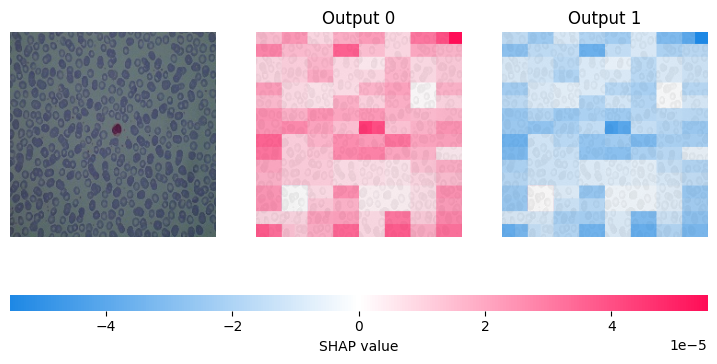

In [66]:
from PIL import Image
import torchvision.transforms as T

img = Image.open(img_path).convert("RGB")

transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor()
])

img_tensor = transform(img).permute(1,2,0).unsqueeze(0).numpy()

masker = shap.maskers.Image("blur(128,128)", img_tensor[0].shape)
explainer = shap.Explainer(vit_predict, masker)

shap_values = explainer(img_tensor)
shap.image_plot(shap_values, img_tensor)

In [67]:
from PIL import Image
import torchvision.transforms as T
import numpy as np

img = Image.open(img_path).convert("RGB")

transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor()
])

img_tensor = transform(img).permute(1,2,0).unsqueeze(0).numpy()


In [68]:
from PIL import Image
import torchvision.transforms as T
import numpy as np

img = Image.open(img_path).convert("RGB")

transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor()
])

img_tensor = transform(img).permute(1,2,0).unsqueeze(0).numpy()


In [69]:
def vit_predict(images):
    images = torch.tensor(images).permute(0,3,1,2).float().to(device)
    with torch.no_grad():
        outputs = model(images).logits
        probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()


In [70]:
import shap

masker = shap.maskers.Image("blur(128,128)", img_tensor[0].shape)


In [71]:
explainer = shap.Explainer(vit_predict, masker)


In [72]:
shap_values = explainer(img_tensor)


  0%|          | 0/498 [00:00<?, ?it/s]

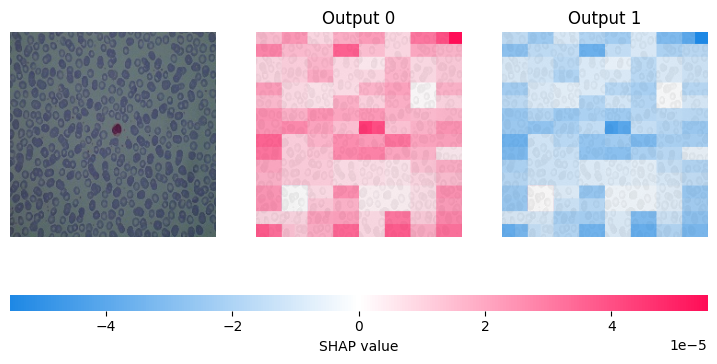

In [73]:
shap.image_plot(shap_values, img_tensor)


In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy :", accuracy_score(y_val, val_pred))
print("Precision:", precision_score(y_val, val_pred))
print("Recall   :", recall_score(y_val, val_pred))
from sklearn.metrics import f1_score
print("F1-score:", f1_score(y_val, val_pred))



Accuracy : 0.90625
Precision: 0.904
Recall   : 1.0
F1-score: 0.9495798319327731


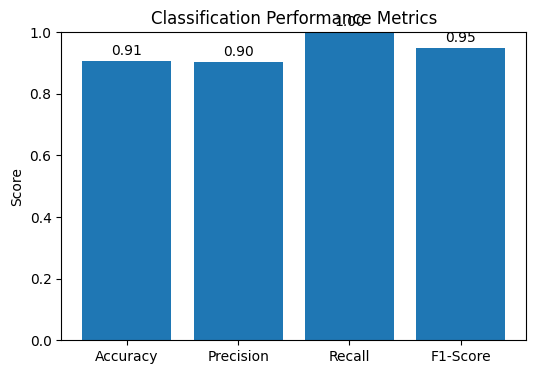

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define metrics (moved from cell fsTf0HuXAKIp)
accuracy  = accuracy_score(y_val, val_pred)
precision = precision_score(y_val, val_pred)
recall    = recall_score(y_val, val_pred)
f1        = f1_score(y_val, val_pred)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values  = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Classification Performance Metrics")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

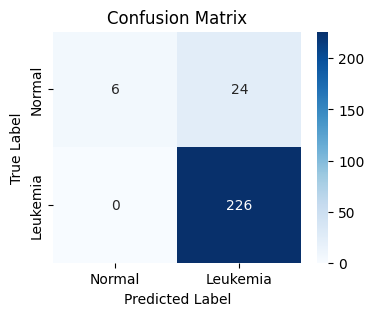

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Leukemia"],
            yticklabels=["Normal", "Leukemia"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [77]:
y_true = y_val                      # true labels (0/1)
y_pred_prob = svm.predict_proba(X_val_hho)[:, 1]   # probabilities (0–1)


In [78]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


In [79]:
from sklearn.metrics import f1_score
print("F1-score:", f1_score(y_val, val_pred))


F1-score: 0.9495798319327731


In [80]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    brier_score_loss,
    log_loss
)
import numpy as np

# Step 1: Define variables again (IMPORTANT)
y_true = y_val.astype(float)
y_prob = svm.predict_proba(X_val_hho)[:, 1]

# Step 2: Regression metrics
mse  = mean_squared_error(y_true, y_prob)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_prob)
r2   = r2_score(y_true, y_prob)

# Step 3: Brier score & Log loss
brier  = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)

print(f"MSE        : {mse:.6f}")
print(f"RMSE       : {rmse:.6f}")
print(f"MAE        : {mae:.6f}")
print(f"R²         : {r2:.4f}")
print(f"Brier Score: {brier:.6f}")
print(f"Log Loss   : {logloss:.6f}")


MSE        : 0.005703
RMSE       : 0.075517
MAE        : 0.014496
R²         : 0.9449
Brier Score: 0.005703
Log Loss   : 0.023623


In [81]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Classification metrics
accuracy  = accuracy_score(y_val, val_pred)
precision = precision_score(y_val, val_pred)
recall    = recall_score(y_val, val_pred)
f1        = f1_score(y_val, val_pred)

classification_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
})

classification_table


,Metric,Value
0,Accuracy,0.90625
1,Precision,0.90400
2,Recall,1.00000
3,F1-Score,0.94958


In [82]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, brier_score_loss, log_loss
import numpy as np

# Regression metrics on probability outputs
y_true = y_val.astype(float)
y_prob = svm.predict_proba(X_val_hho)[:, 1]

mse  = mean_squared_error(y_true, y_prob)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_prob)
r2   = r2_score(y_true, y_prob)
brier = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, y_prob)

regression_table = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R² Score", "Brier Score", "Log Loss"],
    "Value": [mse, rmse, mae, r2, brier, logloss]
})

regression_table


,Metric,Value
0,MSE,0.005703
1,RMSE,0.075517
2,MAE,0.014496
3,R² Score,0.944877
4,Brier Score,0.005703
5,Log Loss,0.023623


In [83]:
combined_table = pd.DataFrame({
    "Category": ["Classification"]*4 + ["Regression"]*6,
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1-Score",
        "MSE", "RMSE", "MAE", "R² Score", "Brier Score", "Log Loss"
    ],
    "Value": [
        accuracy, precision, recall, f1,
        mse, rmse, mae, r2, brier, logloss
    ]
})

combined_table


,Category,Metric,Value
0,Classification,Accuracy,0.906250
1,Classification,Precision,0.904000
2,Classification,Recall,1.000000
3,Classification,F1-Score,0.949580
4,Regression,MSE,0.005703
5,Regression,RMSE,0.075517
6,Regression,MAE,0.014496
7,Regression,R² Score,0.944877
8,Regression,Brier Score,0.005703
9,Regression,Log Loss,0.023623


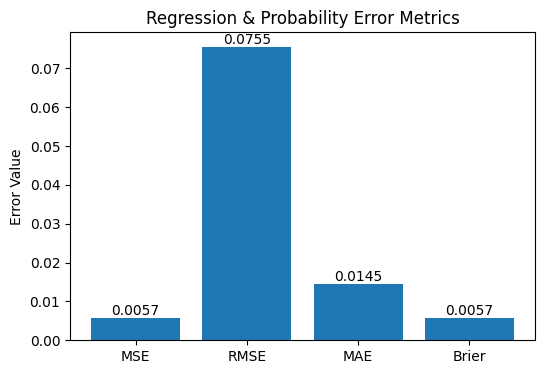

In [84]:
reg_metrics = ["MSE", "RMSE", "MAE", "Brier"]
reg_values  = [mse, rmse, mae, brier]

plt.figure(figsize=(6,4))
plt.bar(reg_metrics, reg_values)
plt.ylabel("Error Value")
plt.title("Regression & Probability Error Metrics")

for i, v in enumerate(reg_values):
    plt.text(i, v, f"{v:.4f}", ha='center', va='bottom')

plt.show()


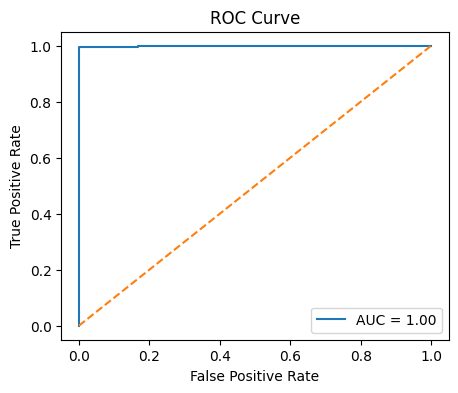

In [85]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


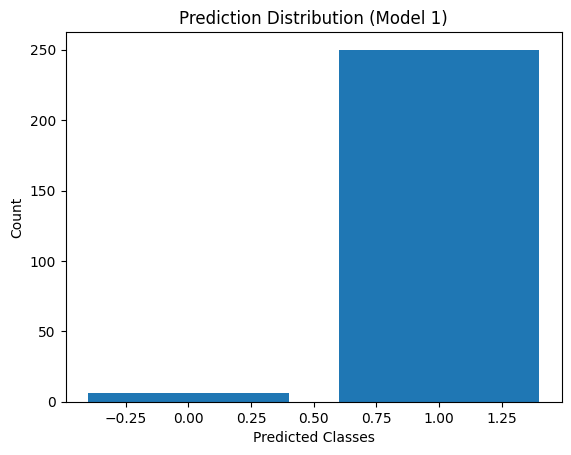

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# Count each class using val_pred
unique, counts = np.unique(val_pred, return_counts=True)

# Plot
plt.figure()
plt.bar(unique, counts)
plt.xlabel("Predicted Classes")
plt.ylabel("Count")
plt.title("Prediction Distribution (Model 1)")
plt.show()

In [87]:
import numpy as np
import torch

# Ensure model is in evaluation mode
model.eval()

vit_y_pred_proba = []
vit_y_pred = []

# Iterate through the validation loader to get predictions and probabilities
with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        outputs = model(images).logits
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        vit_y_pred_proba.extend(probabilities.cpu().numpy())
        vit_y_pred.extend(predictions.cpu().numpy())

# Convert lists to numpy arrays
vit_y_pred_proba = np.array(vit_y_pred_proba)
vit_y_pred = np.array(vit_y_pred)

# Save both
np.save("model_deit_y_pred.npy", vit_y_pred)
np.save("model_deit_y_pred_proba.npy", vit_y_pred_proba)

print("DeiT model predictions and probabilities saved for the validation set.")

DeiT model predictions and probabilities saved for the validation set.


In [88]:
import numpy as np

# Use the already computed predictions and probabilities from Model-1 (SVM)
# val_pred contains the class labels (0 or 1)
# y_pred_prob contains the prediction probabilities for class 1

y_pred = val_pred
y_pred_proba = y_pred_prob

np.save("model1_y_pred.npy", y_pred)
np.save("model1_y_pred_proba.npy", y_pred_proba)

print("Model 1 (SVM) predictions and probabilities saved.")

Model 1 (SVM) predictions and probabilities saved.


In [89]:
import numpy as np

SAVE_PATH = '/content/drive/MyDrive/Leukemia_Model1/'

np.save(SAVE_PATH + "model1_y_pred.npy",       val_pred)
np.save(SAVE_PATH + "model1_y_pred_proba.npy", svm.predict_proba(X_val_hho))
np.save(SAVE_PATH + "model1_y_true.npy",       y_val)

print("✅ Saved! Samples:", len(val_pred))
print("pred shape :",  val_pred.shape)
print("proba shape:", svm.predict_proba(X_val_hho).shape)
print("true shape :",  y_val.shape)

✅ Saved! Samples: 256
pred shape : (256,)
proba shape: (256, 2)
true shape : (256,)
